# Compare M1 mechanisms: OnlyAttendance, Payoff, Attendance, and ICSM

This notebook adapts **Figure 5 panels A and B** (`PaperFigures/Fig5.ipynb`) to the unconditioned (M1) error-driven models plus the focal-region (ICSM) agent:

| Model | Teaching signal / rule |
|---|---|
| **Payoff-M1** | bar payoff only |
| **OnlyAttendance-M1** | exponentially smoothed own attendance only |
| **Attendance-M1** | mixture $\mathrm{bias}\cdot\overline{\mathrm{go}} + (1-\mathrm{bias})\cdot\mathrm{payoff}$ |
| **ICSM** (`FocalRegionAgent`) | match current history to focal schemata |

Shared simulation settings match Fig. 5 (same treatments, rounds, and episodes). Free parameters that a model does not use are ignored. A later cell repeats the comparison at each model's MLE fit when one exists.

**Panel A** — speed of convergence (mean score / threshold vs round).

**Panel B** — efficiency vs inequality (2-D KDE of bounded efficiency vs Gini; OnlyAttendance omitted).

In [38]:
import sys
sys.path.append('../src')

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm.auto import tqdm

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.interaction import Performer
from Classes.cognitive_model_agents import (
    PayoffM1, AttendanceM1, OnlyAttendanceM1,
    FocalRegionAgent,
    # PayoffM2, AttendanceM2, OnlyAttendanceM2,
)

## 1. Shared parameters and treatments

Treatments are the same $(N, \theta)$ pairs used in Fig. 5. `bias` and `forget` are ignored by Payoff-M1; `bias` is ignored by OnlyAttendance-M1; ICSM uses `len_history` (and optional `max_regions` / `c`) and ignores the RL rates.

In [39]:
free_parameters = {
    'inverse_temperature': 8,
    'learning_rate': 0.2,
    'bias': 0.7,       # Attendance-M1: weight on smoothed attendance
    'forget': 0.8,   # decay of average_go (OnlyAttendance and Attendance)
    'len_history': 2,  # ICSM / FocalRegionAgent
    'max_regions': 6,
}

simulation_parameters = {
    'num_rounds': 100,
    'num_episodes': 200,
    'verbose': False,
}

list_fixed_parameters = [
    (2, 0.5),
    (3, 1 / 3), (3, 2 / 3),
    (4, 1 / 4), (4, 0.5), (4, 3 / 4),
]

MODEL_CLASSES = [
    OnlyAttendanceM1, PayoffM1, AttendanceM1, FocalRegionAgent,
    # OnlyAttendanceM2, PayoffM2, AttendanceM2
]

# Labels and colours are keyed by mechanism (or full name when there is no -M suffix).
MECHANISM_LABEL = {
    'OnlyAttendance': 'Only attendance',
    'Payoff': 'Payoff RL',
    'Attendance': 'Attendance + payoff',
    'ICSM': 'Cognitive schemata (ICSM)',
}
MECHANISM_COLOR = {
    'OnlyAttendance': '#ff7f0e',
    'Payoff': '#1f77b4',
    'Attendance': '#e377c2',
    'ICSM': '#2ca02c',
}

model_display = {}
model_palette = {}
for model_class in MODEL_CLASSES:
    name = model_class.name()               # e.g. 'Payoff-M2' or 'ICSM'
    if name in MECHANISM_LABEL:
        mechanism, label = name, MECHANISM_LABEL[name]
    else:
        mechanism, _, variant = name.rpartition('-')
        label = f'{MECHANISM_LABEL[mechanism]} ({variant})'
    model_display[name] = label
    model_palette[label] = MECHANISM_COLOR[mechanism]
model_order = list(model_display.values())

model_display

{'OnlyAttendance-M1': 'Only attendance (M1)',
 'Payoff-M1': 'Payoff RL (M1)',
 'Attendance-M1': 'Attendance + payoff (M1)',
 'ICSM': 'Cognitive schemata (ICSM)'}

## 2. Simulate all models

In [40]:
def simulate_models(model_classes, free_parameters, list_fixed_parameters,
                    simulation_parameters):
    df_list = []
    jobs = [
        (num_agents, threshold, model_class)
        for num_agents, threshold in list_fixed_parameters
        for model_class in model_classes
    ]
    for num_agents, threshold, model_class in tqdm(jobs, desc='Simulations'):
        fixed_parameters = {
            'num_agents': num_agents,
            'threshold': threshold,
        }
        df_sim = Performer.sim(
            agent_class=model_class,
            fixed_parameters=fixed_parameters,
            free_parameters=free_parameters,
            simulation_parameters=simulation_parameters,
        )
        df_sim['model'] = model_class.name()
        df_list.append(df_sim)
    df = pd.concat(df_list, ignore_index=True)
    df['bounded_score'] = df['score'] / df['threshold']
    df['treatment'] = (
        df['num_agents'].astype(int).astype(str)
        + r', $\theta=$'
        + df['threshold'].round(2).astype(str)
    )
    return df


df2 = simulate_models(
    MODEL_CLASSES, free_parameters, list_fixed_parameters, simulation_parameters
)
df2.head()

Simulations:   0%|          | 0/24 [00:00<?, ?it/s]

OnlyAttendance-M1:   0%|          | 0/200 [00:00<?, ?it/s]

Payoff-M1:   0%|          | 0/200 [00:00<?, ?it/s]

Attendance-M1:   0%|          | 0/200 [00:00<?, ?it/s]

ICSM:   0%|          | 0/200 [00:00<?, ?it/s]

...

OnlyAttendance-M1:   0%|          | 0/200 [00:00<?, ?it/s]

Payoff-M1:   0%|          | 0/200 [00:00<?, ?it/s]

Attendance-M1:   0%|          | 0/200 [00:00<?, ?it/s]

ICSM:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
gm = GetMeasurements(
    data=df2,
    measures=['bounded_efficiency', 'conditional_entropy', 'gini_index', 'attendance'],
    T=20,
)
data = gm.get_measurements()
data.head()

,model,treatment,threshold,num_agents,id_sim,bounded_efficiency,conditional_entropy,gini_index,attendance
0,Attendance-M1,"2, $\theta=$0.5",0.5,2,e80bbaf4-b38d-11f1-9c9d-beb3bfa57af1,0.285714,0.403981,0.166667,0.619048
1,Attendance-M1,"2, $\theta=$0.5",0.5,2,e80d4248-b38d-11f1-9c9d-beb3bfa57af1,-0.142857,0.475489,0.166667,0.690476
2,Attendance-M1,"2, $\theta=$0.5",0.5,2,e80e375c-b38d-11f1-9c9d-beb3bfa57af1,0.428571,0.359613,0.166667,0.595238
3,Attendance-M1,"2, $\theta=$0.5",0.5,2,e80f3166-b38d-11f1-9c9d-beb3bfa57af1,0.523810,0.405639,0.160377,0.547619
4,Attendance-M1,"2, $\theta=$0.5",0.5,2,e810745e-b38d-11f1-9c9d-beb3bfa57af1,0.142857,0.344830,0.166667,0.642857


## 3. Figure 5 panels A and B

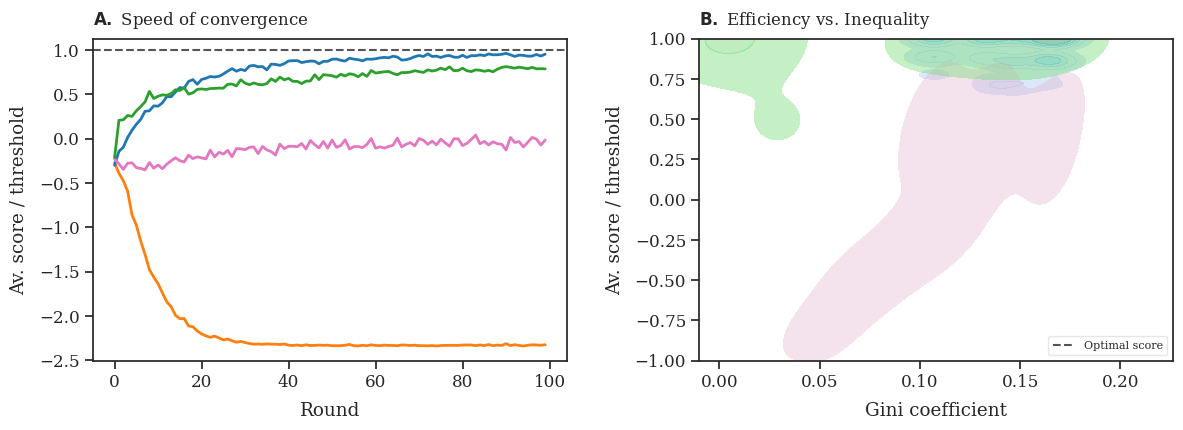

In [ ]:
sns.set_theme(style='ticks', font_scale=1.1)
plt.rcParams['font.family'] = 'serif'

df2_plot = df2.copy()
df2_plot['model'] = df2_plot['model'].map(model_display)
data_plot = data.copy()
data_plot['model'] = data_plot['model'].map(model_display)

fig = plt.figure(figsize=(12, 4.6))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.28, left=0.08, right=0.98, top=0.88, bottom=0.18)
ax_A = fig.add_subplot(gs[0, 0])
ax_B = fig.add_subplot(gs[0, 1])

# A: Speed of convergence
sns.lineplot(
    x='round', y='bounded_score', hue='model',
    hue_order=model_order, palette=model_palette,
    linewidth=2, errorbar=None, data=df2_plot, ax=ax_A,
    legend=False,
)
ax_A.axhline(y=1, color='#555555', linestyle='--', linewidth=1.5, label='Optimal score')
ax_A.set_xlabel('Round', labelpad=8)
ax_A.set_ylabel('Av. score / threshold', labelpad=8)
ax_A.set_title(r'$\bf{A.}$ Speed of convergence', loc='left', pad=10, fontsize=12)

# B: Efficiency vs. inequality (omit OnlyAttendance — its Gini mass sits at 0)
omit_B = [lab for lab in model_order if lab.startswith('Only attendance')]
data_plot_B = data_plot[~data_plot['model'].isin(omit_B)]
hue_order_B = [lab for lab in model_order if lab not in omit_B]
sns.kdeplot(
    x='gini_index', y='bounded_efficiency', hue='model',
    hue_order=hue_order_B, palette=model_palette,
    data=data_plot_B, ax=ax_B,
    fill=True, alpha=0.4, levels=6, thresh=0.05,
    warn_singular=False,
)
ax_B.set_xlabel('Gini coefficient', labelpad=8)
ax_B.set_ylabel('Av. score / threshold', labelpad=8)
ax_B.set_xlim(left=-0.01)
ax_B.set_ylim(-1, 1)
ax_B.set_title(r'$\bf{B.}$ Efficiency vs. Inequality', loc='left', pad=10, fontsize=12)

model_handles, model_labels = ax_B.get_legend_handles_labels()
# ax_B.get_legend().remove()
opt_handle, opt_label = ax_A.get_legend_handles_labels()
ax_B.legend(
    handles=model_handles + opt_handle,
    labels=model_labels + opt_label,
    loc='lower right',
    frameon=True,
    facecolor='white',
    edgecolor='#e0e0e0',
    fontsize=8,
)

fig.savefig(PATHS['exploratory_figures'] / 'compare_M1_attendance_payoff_AB.png',
            dpi=300, bbox_inches='tight')
plt.show()

## 4. Suggested follow-up analyses

Panels A–B collapse a lot of structure. Useful next cuts:

1. **Attendance dynamics** — mean bar occupancy vs round. OnlyAttendance should saturate near always-go (high occupancy, low scores). Payoff should sit near capacity. Attendance-M1 with `bias=1` should look like OnlyAttendance; lowering `bias` interpolates toward Payoff.
2. **Treatment heterogeneity** — facet A and B by $(N,\theta)$. Inequality and speed often change more with threshold than with $N$.
3. **Coordination / predictability** — `conditional_entropy` (and 2nd-order) vs efficiency. Payoff-M1 can lock into turn-taking (low entropy, high efficiency); attendance-driven $G$ typically does not.
4. **MLE parameters** — replay the same design with `reports/MLE/best_fit.json` instead of shared $\alpha,\beta$. Attendance-M1’s fitted `bias≈0.62` and high `forget` vs OnlyAttendance’s `forget≈0.96` can reverse the ranking in A/B.
5. **Bias sweep** — hold $\alpha,\beta,\mathrm{forget}$ and vary `bias` in Attendance-M1 from 0 (Payoff) to 1 (OnlyAttendance) to see the interpolation on the efficiency–Gini plane.
6. **Single-agent probes** — replay a fixed attendance sequence (as in `test_Payoff_and_Attendance.ipynb`) and plot $P(\mathrm{go})$ to see how each $G$ reacts to overcrowding vs staying home.
7. **Fairness of turn-taking** — player-level Gini over time, or alternation indices from `Utils.indices.AlternationIndex`.
8. **Human overlay** — add human `bounded_score` from `multi-player.csv` as a reference line on panel A (Fig. 5 row 2 style).

The cells below implement (1)–(4).

### 4.1 Attendance vs round and entropy vs efficiency

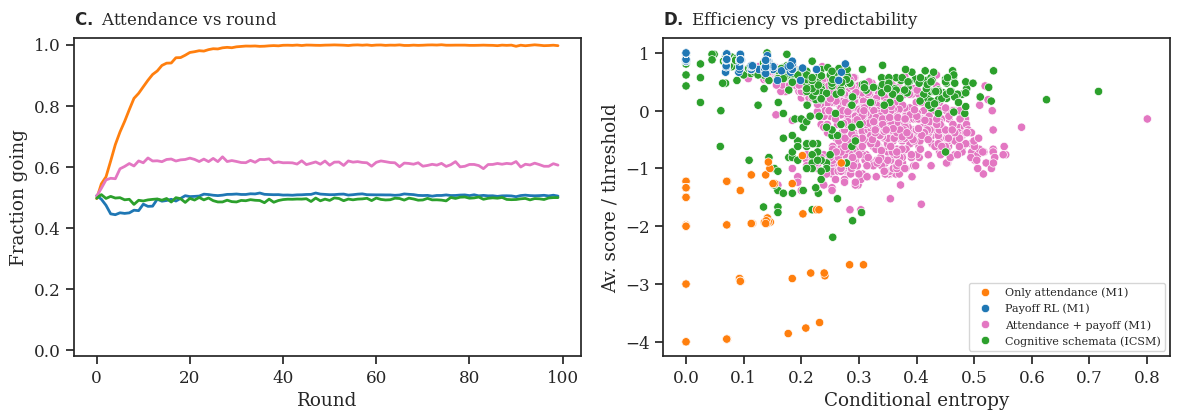

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

sns.lineplot(
    x='round', y='decision', hue='model',
    hue_order=model_order, palette=model_palette,
    linewidth=2, errorbar=None, data=df2_plot, ax=axes[0], legend=False,
)
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Fraction going')
axes[0].set_title(r'$\bf{C.}$ Attendance vs round', loc='left', pad=10, fontsize=12)
axes[0].set_ylim(-0.02, 1.02)

sns.scatterplot(
    x='conditional_entropy', y='bounded_efficiency', hue='model',
    hue_order=model_order, palette=model_palette,
    data=data_plot, ax=axes[1], legend='brief',
)
axes[1].set_xlabel('Conditional entropy')
axes[1].set_ylabel('Av. score / threshold')
axes[1].set_title(r'$\bf{D.}$ Efficiency vs predictability', loc='left', pad=10, fontsize=12)
axes[1].legend(frameon=True, fontsize=8, title=None)

fig.tight_layout()
plt.show()

### 4.2 Convergence faceted by treatment

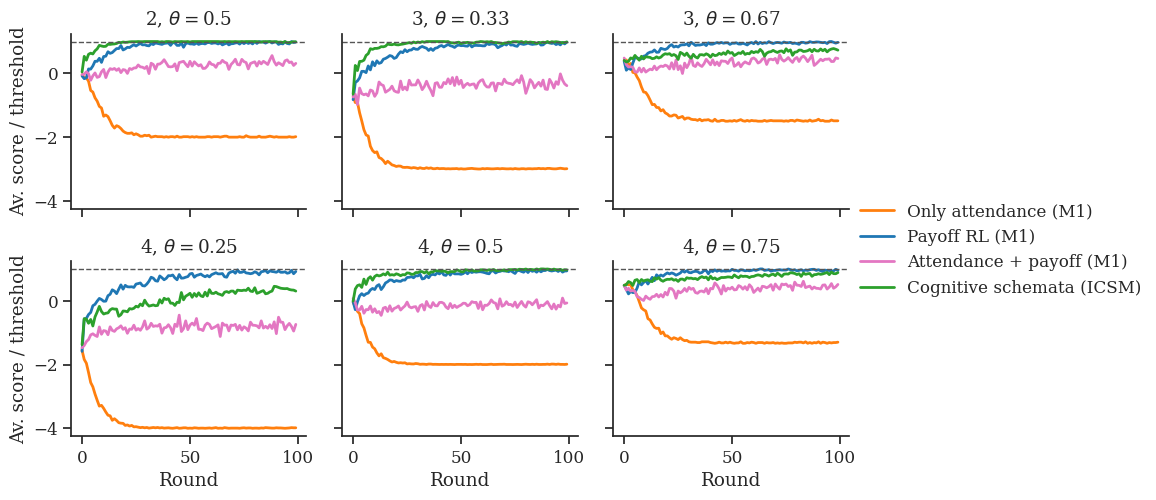

In [ ]:
g = sns.relplot(
    data=df2_plot,
    x='round', y='bounded_score', hue='model',
    hue_order=model_order, palette=model_palette,
    col='treatment', col_wrap=3,
    kind='line', errorbar=None, linewidth=2,
    height=2.6, aspect=1.15, facet_kws={'sharey': True},
)
g.set_axis_labels('Round', 'Av. score / threshold')
g.set_titles('{col_name}')
for ax in g.axes.flatten():
    ax.axhline(1, color='#555555', linestyle='--', linewidth=1)
g._legend.set_title('')
plt.show()

### 4.3 Replay at MLE best-fit parameters

Each model uses its own fitted $\alpha,\beta$ (and `bias`/`forget` when present). This answers whether the qualitative ranking in A/B survives the parameters that best describe humans.

fits = {}
with open(PATHS['parameter_fit_results'] / 'best_fit.json') as f:
    for line in f:
        rec = json.loads(line)
        fits[rec['model_name']] = rec

unfitted = [c.name() for c in MODEL_CLASSES if c.name() not in fits]
if unfitted:
    print('No MLE fit in best_fit.json for:', ', '.join(unfitted))

mle_rows = []
for model_class in MODEL_CLASSES:
    name = model_class.name()
    if name not in fits:
        continue
    print(name, fits[name]['free_parameters'])
    params = {
        'inverse_temperature': 8,
        'learning_rate': 0.2,
        'bias': 1,
        'forget': 0.8,
        'len_history': 2,
        'max_regions': 5,
    }
    params.update(fits[name]['free_parameters'])
    mle_rows.append(
        simulate_models(
            [model_class], params, list_fixed_parameters, simulation_parameters
        )
    )

if not mle_rows:
    raise ValueError(
        'best_fit.json has no fits for the selected MODEL_CLASSES '
        '(only M1 variants are fitted); switch MODEL_CLASSES back to M1 '
        'or skip this section.'
    )

df_mle = pd.concat(mle_rows, ignore_index=True)
gm_mle = GetMeasurements(
    data=df_mle,
    measures=['bounded_efficiency', 'gini_index', 'conditional_entropy'],
)
data_mle = gm_mle.get_measurements()

df_mle_plot = df_mle.copy()
df_mle_plot['model'] = df_mle_plot['model'].map(model_display)
data_mle_plot = data_mle.copy()
data_mle_plot['model'] = data_mle_plot['model'].map(model_display)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
sns.lineplot(
    x='round', y='bounded_score', hue='model',
    hue_order=model_order, palette=model_palette,
    linewidth=2, errorbar=None, data=df_mle_plot, ax=axes[0], legend=False,
)
axes[0].axhline(1, color='#555555', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Av. score / threshold')
axes[0].set_title(r'$\bf{A.}$ Convergence at MLE fits', loc='left', pad=10, fontsize=12)

sns.scatterplot(
    x='gini_index', y='bounded_efficiency', hue='model',
    hue_order=model_order, palette=model_palette,
    data=data_mle_plot, ax=axes[1],
)
axes[1].set_xlabel('Gini coefficient')
axes[1].set_ylabel('Av. score / threshold')
axes[1].set_title(r'$\bf{B.}$ Efficiency vs inequality (MLE)', loc='left', pad=10, fontsize=12)
axes[1].legend(frameon=True, fontsize=8, title=None)
fig.tight_layout()
plt.show()